In [1]:
import os

In [2]:
audio_files = os.listdir(r'C:\Users\User\OneDrive\Desktop\testing kaggle code for final project\acoustic_audio')

In [3]:
for files in audio_files:
    print(files)
print(len(audio_files))

Atlantic_Spotted_Dolphin
Bearded_Seal
Beluga_White_Whale
Bottlenose_Dolphin
Bowhead_Whale
Clymene_Dolphin
Common_Dolphin
False_Killer_Whale
Fin_Finback_Whale
Frasers_Dolphin
Grampus_Rissos_Dolphin
Harp_Seal
Humpback_Whale
Killer_Whale
Leopard_Seal
Long_Finned_Pilot_Whale
Melon_Headed_Whale
Minke_Whale
Narwhal
Northern_Right_Whale
Pantropical_Spotted_Dolphin
Ross_Seal
Rough_Toothed_Dolphin
Short_Finned_Pilot_Whale
Southern_Right_Whale
Sperm_Whale
Spinner_Dolphin
Striped_Dolphin
Walrus
Weddell_Seal
White_beaked_Dolphin
White_sided_Dolphin
32


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install librosa



In [6]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import librosa
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa.display
import seaborn as sns
import warnings
from glob import glob
import pandas as pd

warnings.filterwarnings('ignore')

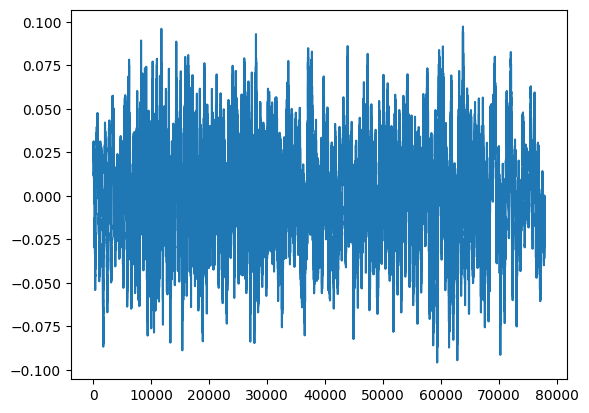

In [8]:
file_name = r'C:\Users\User\OneDrive\Desktop\testing kaggle code for final project\acoustic_audio\Atlantic_Spotted_Dolphin\6102500A.wav'
data,sample_rate = librosa.load(file_name)
sns.lineplot(data=data)
file = ipd.Audio(file_name)
ipd.display(file)

In [9]:
librosa.feature.mfcc(y=data,sr=sample_rate,n_mfcc=40)

array([[-358.79312   , -330.39758   , -328.2445    , ..., -331.2832    ,
        -330.5174    , -327.0122    ],
       [ 101.2078    ,  100.057686  ,  102.16527   , ...,   95.84267   ,
          99.229004  ,  100.38611   ],
       [  20.94474   ,   19.931187  ,   19.13977   , ...,   17.691536  ,
          14.172577  ,   18.196014  ],
       ...,
       [   5.281131  ,    8.177263  ,    5.0538836 , ...,    4.602825  ,
           2.963489  ,    1.1148801 ],
       [  -1.1336647 ,    1.7022183 ,   -1.0695008 , ...,    0.67783356,
           0.719513  ,   -3.2357798 ],
       [  -3.4731255 ,    2.132422  ,    2.1643836 , ...,    2.8333983 ,
           1.3905787 ,   -2.5506704 ]], dtype=float32)

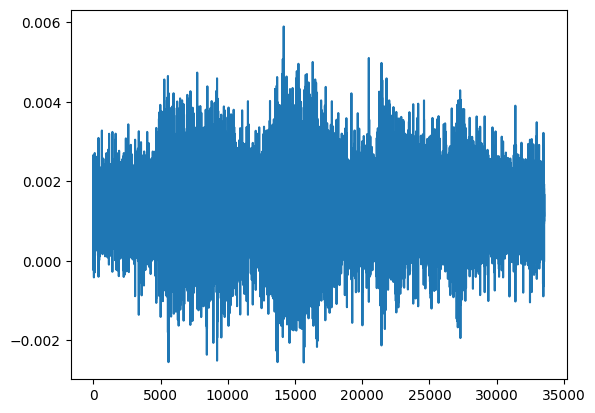

In [10]:
file_path = r"C:\Users\User\OneDrive\Desktop\testing kaggle code for final project\acoustic_audio\Atlantic_Spotted_Dolphin\6102500C.wav"
audio_data,sample_rate = librosa.load(file_path)
sns.lineplot(audio_data)
ipd.display(ipd.Audio(file_path))

In [11]:
pip install pydub

Note: you may need to restart the kernel to use updated packages.


Frame Rate: 60600 Hz
Channels: 1


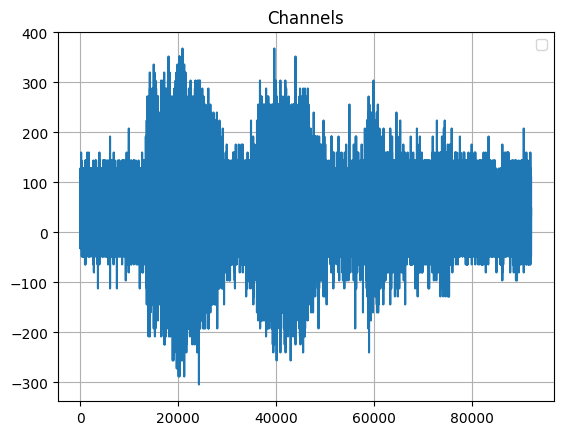

In [12]:
from pydub import AudioSegment

try:
  # Open the wav audio file using pydub
  sound = AudioSegment.from_wav(file_path)

  # Get the frame rate (number of frames per second)
  frame_rate = sound.frame_rate

  # Get the number of channels (mono or stereo)
  channels = sound.channels

  # Access the audio data (raw bytes)
  audio_data = sound.raw_data

  print(f"Frame Rate: {frame_rate} Hz")
  print(f"Channels: {channels}")
  
  # You can perform further processing on the audio data here

except OSError as e:
  print(f"Error reading wav file: {e}")

audio_data = sound.get_array_of_samples()
plt.plot(audio_data)
plt.title("Channels")
plt.legend()
plt.grid(True)

In [13]:
mfcc = librosa.feature.mfcc(y=data,sr=sample_rate,n_mfcc=40)
mfcc_mean = np.mean(mfcc.T,axis=0)
mfcc_mean

array([-2.7366238e+02,  5.8997185e+01,  8.3549422e-01,  5.0788792e+01,
        3.6858144e+00,  7.8738852e+00,  5.1314778e+00,  2.3517380e+01,
       -2.8433843e+00,  1.1646706e+01,  6.1197906e+00,  1.2044542e+01,
        1.6504314e+00,  7.9740400e+00,  5.6677728e+00,  4.1275249e+00,
        4.1625800e+00,  8.7413759e+00, -7.6351218e-02,  7.4044814e+00,
        2.5958312e+00,  5.6856070e+00,  7.1630496e-01,  5.5945530e+00,
        1.7341508e+00,  5.1775198e+00,  1.5418551e+00,  4.6526370e+00,
        1.4321928e+00,  4.1401334e+00,  5.5390066e-01,  2.6151097e+00,
        2.9788524e-01,  4.1969028e+00, -6.0964572e-01,  2.7452819e+00,
        4.8972070e-01,  1.7813183e+00, -5.5249417e-01,  2.6477158e+00],
      dtype=float32)

In [14]:
root_directory = r"C:\Users\User\OneDrive\Desktop\testing kaggle code for final project\acoustic_audio"

def feature_extractor(file):
    audio_data,sample_rate = librosa.load(file,duration=1)
    mfcc_feature = librosa.feature.mfcc(y=audio_data,sr=sample_rate,n_mfcc=40)
    scaled_feature = np.mean(mfcc_feature.T,axis=0)
    return scaled_feature

In [15]:
category = os.listdir(root_directory)

In [16]:
mfccs_feature = []
classes = []
for folder in os.listdir(root_directory):
    folder_path = os.path.join(root_directory,folder)
    for file in os.listdir(folder_path)[:5000]:
        file_path = os.path.join(folder_path,file)
        mfccs_feature.append(feature_extractor(file_path))
        classes.append(folder)

In [17]:
df = pd.DataFrame({'MFCC_Features': mfccs_feature, 'Class': classes})
df.shape

(1697, 2)

In [18]:
new_df = df.sample(1697)
new_df.head()

,MFCC_Features,Class
509,"[-40.99272, 17.36835, -6.54868, -5.9184813, -3...",Frasers_Dolphin
806,"[-147.72278, 50.571644, 16.325302, 23.73164, 2...",Long_Finned_Pilot_Whale
458,"[-290.68192, -199.62085, -33.01971, 39.937073,...",Frasers_Dolphin
268,"[-235.57852, 46.812088, 1.8942122, 7.7244644, ...",Clymene_Dolphin
312,"[-270.8699, 3.093487, 17.044044, 14.974096, 5....",Common_Dolphin


In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense

In [21]:
lbl = LabelEncoder()
y = lbl.fit_transform(new_df['Class'])
X = np.array(new_df['MFCC_Features'].tolist())
y = np.array(y.tolist())

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
model = Sequential()
model.add(Dense(100,activation='relu',input_shape=(40,)))
model.add(Dropout(0.5))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(225,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(32,activation='softmax'))

In [45]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [46]:
history = model.fit(X_train,y_train,epochs=30,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/30


43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0342 - loss: 62.8102 - val_accuracy: 0.0382 - val_loss: 4.4643
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0387 - loss: 20.0354 - val_accuracy: 0.0794 - val_loss: 3.4050
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0429 - loss: 12.1492 - val_accuracy: 0.0676 - val_loss: 3.3051
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0370 - loss: 7.8864 - val_accuracy: 0.0441 - val_loss: 3.4075
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0456 - loss: 6.0473 - val_accuracy: 0.0441 - val_loss: 3.4270
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0335 - loss: 4.9907 - val_accuracy: 0.0382 - val_loss: 3.4413
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0409 - loss: 4.2621 - val_accuracy: 0.0353 - val_loss: 3.4427
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0430 - loss: 3.8598 - val_accuracy: 0.0353 - val_loss: 3.4399

<Axes: >

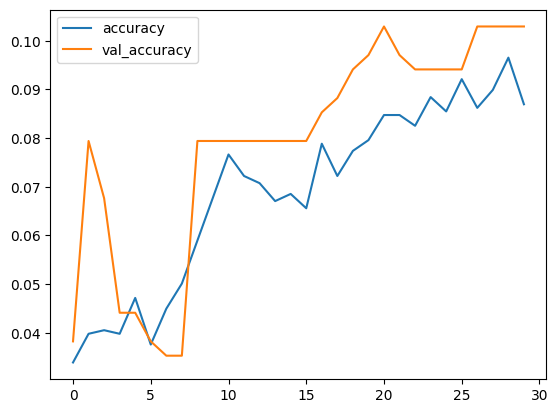

In [47]:
history_df = pd.DataFrame({'accuracy': history.history['accuracy'], 'val_accuracy': history.history['val_accuracy']})
history_df.plot()

In [48]:
model.evaluate(X_test,y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1077 - loss: 3.2938 


[3.312803030014038, 0.10294117778539658]

In [49]:
y_pred = model.predict(X_test)
y_pred = (y_pred>0.5).astype(int)
y_pred = np.argmax(y_pred,axis=1)
y_pred

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([ 0,  0,  0,  0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, 21,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

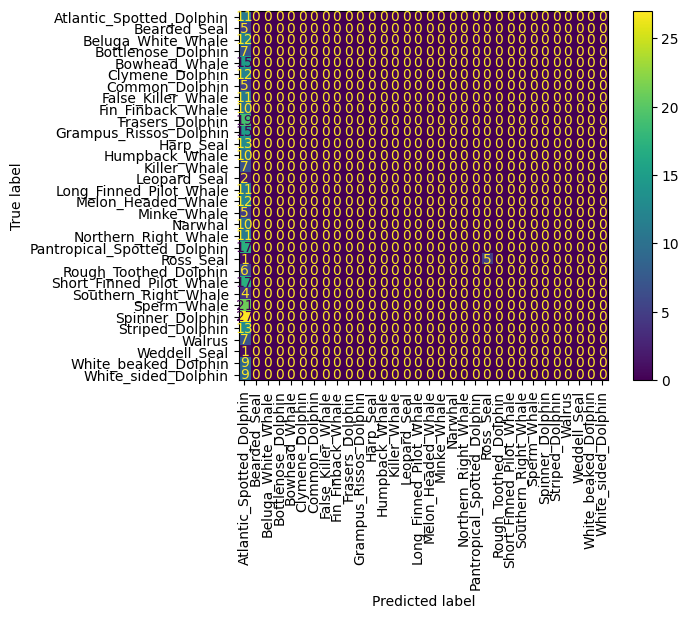

In [50]:
cnf = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cnf,display_labels=lbl.classes_).plot()
plt.xticks(rotation=90)
plt.show()